### Antigenic Distance Prediction


For any given **RBD<sub>i</sub>** and **RBD<sub>j</sub>**  mutant sequences, use the following script to calculate their antigenic distance:

`phenotype_inference/ad_prediction_single_sequence.py`

In [2]:
!python phenotype_inference/code/ad_prediction_single_sequence.py --seq1 'NITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTYGVGYQPYRVVVLSFELLHAPATVCGPKKST'\
    --seq2 'NITNLCPFDEVFNATRFASVYAWNRKRISNCVADYSVLYNLAPFFTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGNIADYNYKLPDDFTGCVIAWNSNKLDSKVSGNYNYLYRLFRKSNLKPFERDISTEIYQAGNKPCNGVAGFNCYFPLRSYSFRPTYGVGHQPYRVVVLSFELLHAPATVCGPKKST'\
    --loadmodel wt

Loading ESM model and wt trained evoRBD weights...
------------------------------
Sequence 1: NITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTYGVGYQPYRVVVLSFELLHAPATVCGPKKST
Sequence 2: NITNLCPFDEVFNATRFASVYAWNRKRISNCVADYSVLYNLAPFFTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGNIADYNYKLPDDFTGCVIAWNSNKLDSKVSGNYNYLYRLFRKSNLKPFERDISTEIYQAGNKPCNGVAGFNCYFPLRSYSFRPTYGVGHQPYRVVVLSFELLHAPATVCGPKKST
Predicted Antigenic Distance: 1.7311
------------------------------


For the data and figures used in the paper, please refer to the workflow below:

In [3]:
import os
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import torch.nn as nn
from esm import pretrained
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from scipy.stats import t, spearmanr
from torch.utils.data import DataLoader, Dataset
from sklearn.linear_model import LinearRegression

/home/zhangl/miniconda3/envs/SaProt/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
class RawSequenceDataset(Dataset):
    def __init__(self, seq_list):
        self.seq_list = seq_list

    def __len__(self):
        return len(self.seq_list)

    def __getitem__(self, idx):
        return str(idx), self.seq_list[idx]

class SequenceInteractionModel(nn.Module):
    def __init__(self, esm_model):
        super().__init__()
        self.esm_model = esm_model.eval()        
        for p in self.esm_model.parameters():   
            p.requires_grad = False

    def forward(self, seq_tokens):
        out = self.esm_model(seq_tokens, repr_layers=[self.esm_model.num_layers])
        rep = out["representations"][self.esm_model.num_layers][:, 1:-1, :]   
        rep = rep.flatten(start_dim=1)    
        return rep

In [5]:
def ad_prediction(seqs, loadmodel='wt', batchsize=32):
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    num_gpus = torch.cuda.device_count()
    print(f"Running on {device}, detected {num_gpus} GPUs.")
    print("Loading ESM model...")
    esm_model, alphabet = pretrained.esm2_t33_650M_UR50D()
    batch_converter = alphabet.get_batch_converter()

    ds = RawSequenceDataset(seqs)

    dl = DataLoader(ds,
                    batch_size=batchsize,
                    shuffle=False,
                    num_workers=8, 
                    collate_fn=batch_converter,
                    pin_memory=True)

    model = SequenceInteractionModel(esm_model)
    model_paths = {
        'ba5': 'phenotype_inference/model_trained/evoRBD_ba5_trained.pth',
        'wt': 'phenotype_inference/model_trained/evoRBD_wt_trained.pth',
    }
    
    if loadmodel not in model_paths:
        raise ValueError(f"Unknown model type: {loadmodel}. Choose from {list(model_paths.keys())}")
        
    loadmodelpath = model_paths[loadmodel]
    
    if os.path.isfile(loadmodelpath):
        sd = torch.load(loadmodelpath, map_location='cpu')
        sd = {k.replace('module.', ''): v for k, v in sd.items()}
        model.load_state_dict(sd, strict=False)    
        print(f'Loaded fine-tuned weights from {loadmodel}')
    else:
        print(f"Warning: Model file not found at {loadmodelpath}. Using raw ESM2 weights.")
        
    model.to(device)

    if num_gpus > 1:
        model = nn.DataParallel(model)

    embeddings = []
    print("Starting Inference...")
    with torch.no_grad():
        for _, _, batch_tokens in tqdm(dl, desc='Embedding'):
            batch_tokens = batch_tokens.to(device, non_blocking=True)
            emb_batch = model(batch_tokens)
            embeddings.append(emb_batch.cpu()) 

    emb_tensor = torch.cat(embeddings, dim=0)         
    print('AD matrix calculating...') 

    try:
        emb_tensor_gpu = emb_tensor.to(device)
        dist_mat = torch.cdist(emb_tensor_gpu, emb_tensor_gpu, p=1) * 0.1
        dist_mat = dist_mat.cpu()
        del emb_tensor_gpu
        torch.cuda.empty_cache()
    except RuntimeError as e:
        print(f"GPU calculation failed (likely OOM), falling back to CPU. Error: {e}")
        dist_mat = torch.cdist(emb_tensor, emb_tensor, p=1) * 0.1

    assert len(seqs) == dist_mat.size(0)
    
    dist_df = pd.DataFrame(
        dist_mat.numpy(),
        index=seqs,
        columns=seqs
    )
    
    return dist_df 

In [6]:
def ad_long_format(data_path):
    df = pd.read_csv(data_path)
    seqs = df['mutant_seq'].tolist()
    ad_pred_wt = ad_prediction(seqs, loadmodel='wt', batchsize=32)
    ad_pred_ba5 = ad_prediction(seqs, loadmodel='ba5', batchsize=32)
    
    mask = np.tril(np.ones(ad_pred_wt.shape), k=-1).astype(bool)
    rows, cols = np.where(mask)
    
    seq1_list = ad_pred_wt.index[rows]
    seq2_list = ad_pred_wt.columns[cols]
    wt_dists = ad_pred_wt.values[rows, cols]
    ba5_dists = ad_pred_ba5.values[rows, cols]
    df_actual = df.set_index('mutant_seq')
    
    actual_dists = df_actual.values[rows, cols]
    
    result_df = pd.DataFrame({
        'seq1': seq1_list,
        'seq2': seq2_list,
        'ad_pre_wt': wt_dists,
        'ad_pre_ba5': ba5_dists,
        'actual distance': actual_dists
    })
    
    return result_df

In [7]:
def normalize_ad(series: pd.Series) -> pd.Series:
    q_low = series.quantile(0.01)
    q_high = series.quantile(0.99)
    clipped = series.clip(lower=q_low, upper=q_high)
    denom = q_high - q_low
    return (clipped - q_low) / denom

In [9]:
ad_pred_hu = ad_long_format('phenotype_inference/external_validation_dataset/assay_data_Hu.csv')
ad_pred_du = ad_long_format('phenotype_inference/external_validation_dataset/assay_data_Du.csv')
ad_pred_hu['source'] = 'Hu S, et al. 2023.'
ad_pred_du['source'] = 'Du P, et al. 2024.'

Running on cuda, detected 2 GPUs.
Loading ESM model...
Loaded fine-tuned weights from wt
Starting Inference...


Embedding: 100%|██████████| 1/1 [00:03<00:00,  3.16s/it]


AD matrix calculating...
Running on cuda, detected 2 GPUs.
Loading ESM model...
Loaded fine-tuned weights from ba5
Starting Inference...


Embedding: 100%|██████████| 1/1 [00:02<00:00,  2.50s/it]


AD matrix calculating...
Running on cuda, detected 2 GPUs.
Loading ESM model...
Loaded fine-tuned weights from wt
Starting Inference...


Embedding: 100%|██████████| 1/1 [00:03<00:00,  3.38s/it]


AD matrix calculating...
Running on cuda, detected 2 GPUs.
Loading ESM model...
Loaded fine-tuned weights from ba5
Starting Inference...


Embedding: 100%|██████████| 1/1 [00:03<00:00,  3.31s/it]


AD matrix calculating...


In [10]:
ad_pred_all = pd.concat([ad_pred_hu, ad_pred_du], ignore_index=True)
ad_pred_all['ad_pre_wt_norm'] = normalize_ad(ad_pred_all['ad_pre_wt'])
ad_pred_all['ad_pre_ba5_norm'] = normalize_ad(ad_pred_all['ad_pre_ba5'])
ad_pred_all['ad_pre_bagged'] = 0.5 * (ad_pred_all['ad_pre_wt_norm'] + ad_pred_all['ad_pre_ba5_norm'])

In [11]:
def draw_on_ax(ax, df, target_col, actual_col="Actual distance"):
    plot_data = df[[actual_col, target_col, 'source']].dropna()
    x_val = plot_data[target_col].values
    y_val = plot_data[actual_col].values
    
    rho, p_val = spearmanr(x_val, y_val)
    if p_val < 2e-16:
        p_str = "p < 2e-16"
    else:
        p_str = f"p = {p_val:.0e}"
        
    n_samples = len(x_val)
    n_str = f"N = {n_samples:,}"
    
    x_reshaped = x_val.reshape(-1, 1)
    model = LinearRegression()
    model.fit(x_reshaped, y_val)
    y_fit = model.predict(x_reshaped)
    
    sns.scatterplot(
        data=plot_data, x=target_col, y=actual_col, hue='source', 
        s=60, alpha=0.8, edgecolors='k', linewidths=0.5, ax=ax
    )
    
    order = np.argsort(x_val)
    x_sorted = x_val[order]
    y_fit_sorted = y_fit[order]
    ax.plot(x_sorted, y_fit_sorted, color='#c0392b', linestyle='-', linewidth=2)
    
    n = len(x_val)
    dof = n - 2
    resid = y_val - y_fit
    s_err = np.sqrt(np.sum(resid**2) / dof)
    x_mean = np.mean(x_val)
    Sxx = np.sum((x_val - x_mean) ** 2)
    tval = t.ppf(0.975, dof)
    se_mean = s_err * np.sqrt(1/n + (x_sorted - x_mean)**2 / Sxx)
    ax.fill_between(x_sorted, y_fit_sorted - tval * se_mean, y_fit_sorted + tval * se_mean, 
                    color='#c0392b', alpha=0.15)
    
    annotation_text = f"Spearman's ρ = {rho:.3f}\n{p_str}\n{n_str}"
    
    ax.text(0.05, 0.95, annotation_text, transform=ax.transAxes,
            fontsize=16, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='none'))
    
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.set_xlabel('Predicted distance', fontsize=18)
    ax.set_ylabel('Experimental antigenic distance' if ax.get_subplotspec().is_first_col() else '', fontsize=18)
    ax.set_title('')
    ax.get_legend().remove()

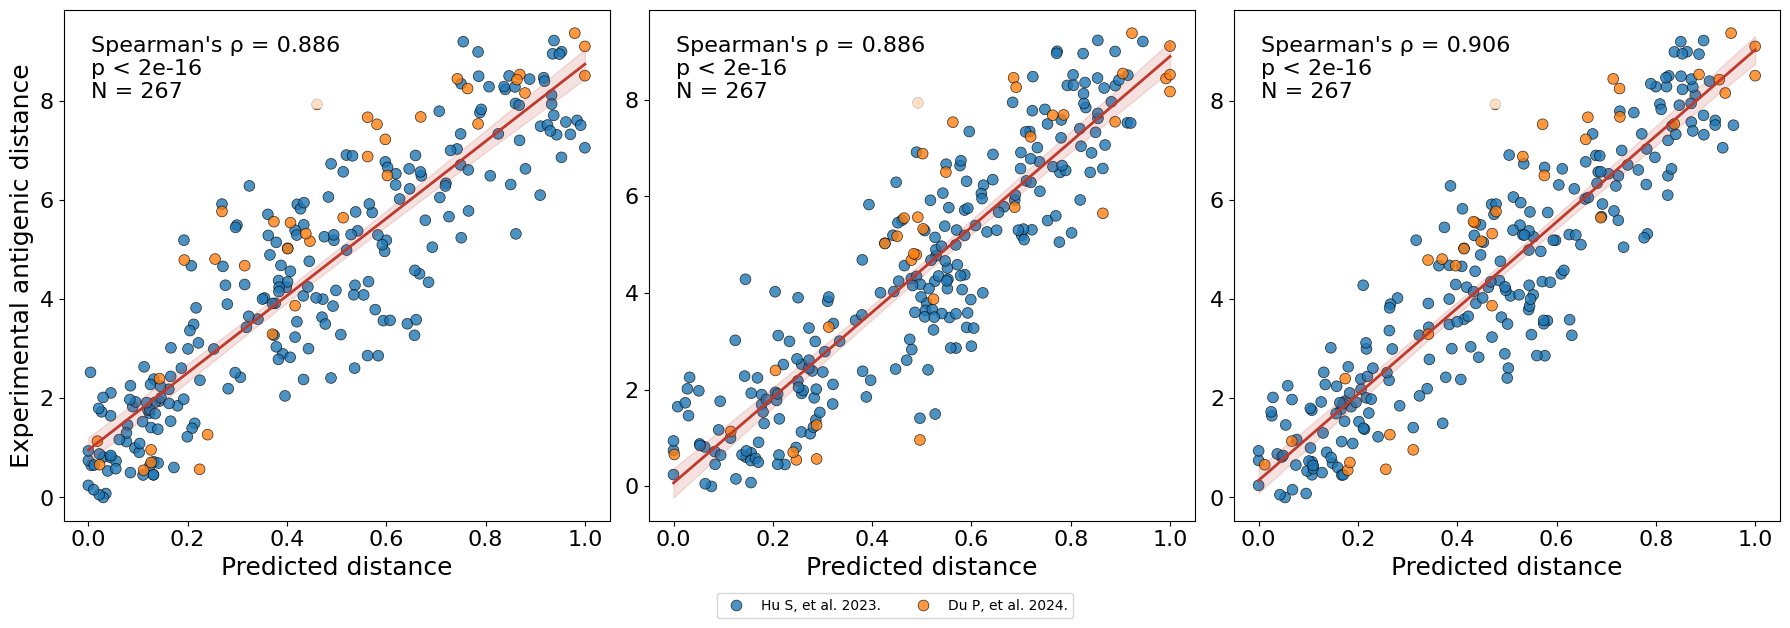

In [12]:
target_columns = ['ad_pre_wt_norm', 'ad_pre_ba5_norm', 'ad_pre_bagged']
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, col in enumerate(target_columns):
    draw_on_ax(axes[i], ad_pred_all, target_col=col, actual_col='actual distance')
    
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05), frameon=True)

plt.tight_layout()
plt.show()

### ACE2 Binding Prediction


For any given **RBD<sub>i</sub>**  mutant sequences, use the following script to calculate its ACE2 binding:

`phenotype_inference/ace2_binding_prediction/rbd_binding_prediction_single_sequence.py`

In [16]:
!cd phenotype_inference/code/ace2_binding_prediction/ && python rbd_binding_prediction_single_sequence.py --seq 'NITNLCPFGEVFNATRFASVYAWNRKRISNCVADYSVLYNSASFSTFKCYGVSPTKLNDLCFTNVYADSFVIRGDEVRQIAPGQTGKIADYNYKLPDDFTGCVIAWNSNNLDSKVGGNYNYLYRLFRKSNLKPFERDISTEIYQAGSTPCNGVEGFNCYFPLQSYGFQPTYGVGYQPYRVVVLSFELLHAPATVCGPKKST'

/home/zhangl/miniconda3/envs/SaProt/lib/python3.10/site-packages/lightning_utilities/core/imports.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Running inference on cuda
Total mutant_seq to predict: 1
Generating structure embedding for ACE2...
Some weights of EsmForMaskedLM were not initialized from the model checkpoint at configs/saprot_model and are newly initialized: ['esm.embeddings.position_embeddings.weight', 'esm.contact_head.regression.bias', 'esm.contact_head.regression.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Loading ESM model from ../../model_trained/evoRBD_ba5_trained.pth...
Loading Binding MLP from ../../model_trained/ace2binding_trained.pth...
Auto-detected hidden_dim: 256

For the data and figures used in the paper, please refer to the workflow below:

In [17]:
!cd phenotype_inference/code/ace2_binding_prediction/ && python rbd_binding_prediction.py

/home/zhangl/miniconda3/envs/SaProt/lib/python3.10/site-packages/lightning_utilities/core/imports.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Running inference on cuda
Total mutant_seq to predict: 60
Generating structure embedding for ACE2...
Some weights of EsmForMaskedLM were not initialized from the model checkpoint at configs/saprot_model and are newly initialized: ['esm.contact_head.regression.weight', 'esm.contact_head.regression.bias', 'esm.embeddings.position_embeddings.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Loading ESM model from ../../model_trained/evoRBD_ba5_trained.pth...
Loading Binding MLP from ../../model_trained/ace2binding_trained.pth...
Auto-detected hidden_dim: 25

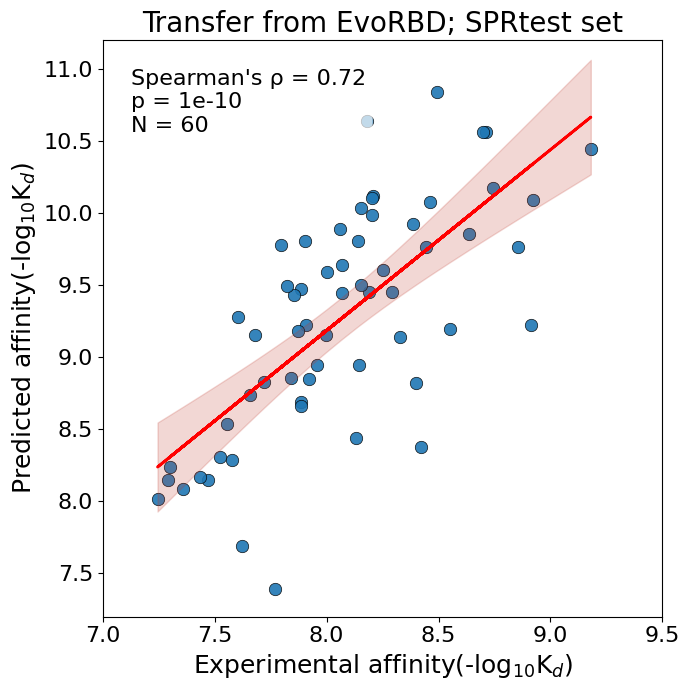

In [18]:
def plot_on_ax(ax, y_test, y_pred, title):
    y_test = np.asarray(y_test)
    y_pred = np.asarray(y_pred)
    
    spearman_corr_test_K, p_val = spearmanr(y_test, y_pred)
    if p_val < 2e-16:
        p_str = "p < 2e-16"
    else:
        p_str = f"p = {p_val:.0e}"
    
    n_samples = len(y_test)
    n_str = f"N = {n_samples:,}"
    y_test_reshaped = y_test.reshape(-1, 1)
    model = LinearRegression()
    model.fit(y_test_reshaped, y_pred)
    y_pred_l = model.predict(y_test_reshaped)
    
    ax.scatter(y_test, y_pred, s=80, alpha=0.9, edgecolors='k', linewidths=0.5)
    ax.plot(y_test, y_pred_l, color='red', linestyle='-', linewidth=2, label='Linear Fit')
    x = y_test.squeeze()                      
    y_fit = np.asarray(y_pred_l).squeeze()    
    y_obs = np.asarray(y_pred).squeeze()     

    n = len(x)
    dof = n - 2
    resid = y_obs - y_fit
    s_err = np.sqrt(np.sum(resid**2) / dof)  
    x_mean = np.mean(x)
    Sxx = np.sum((x - x_mean) ** 2)

    tval = t.ppf(0.975, dof)  
    se_mean = s_err * np.sqrt(1/n + (x - x_mean)**2 / Sxx) 
    ci = tval * se_mean
    lower = y_fit - ci
    upper = y_fit + ci
    order = np.argsort(x)
    ax.fill_between(x[order], lower[order], upper[order], alpha=0.2, label='95% CI', color='#c0392b')
    annotation_text = f"Spearman's ρ = {spearman_corr_test_K:.2f}\n{p_str}\n{n_str}"
    ax.text(0.05, 0.95, annotation_text,
             transform=ax.transAxes,
             fontsize=16,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='none'))
    
    ax.tick_params(axis='both', which='major', labelsize=16)
    
    ax.set_xlim(7, 9.5)
    ax.set_ylim(7.2, 11.2)
    
    ax.set_xlabel('Experimental affinity(-log$_{10}$K$_{d}$)', fontsize=18)
    ax.set_ylabel('Predicted affinity(-log$_{10}$K$_{d}$)', fontsize=18)
    ax.set_title(title, fontsize=20)

csv_path = 'phenotype_inference/code/ace2_binding_prediction/prediction/ace2_binding_cao_pred.csv'
df_pred = pd.read_csv(csv_path)

true_col = 'bind' 
pred_col = 'pred_binding'
plot_data = df_pred[[true_col, pred_col]].dropna()

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
plot_on_ax(
    ax=ax, 
    y_test=plot_data[true_col], 
    y_pred=plot_data[pred_col], 
    title='Transfer from EvoRBD; SPRtest set'
)

plt.tight_layout()
plt.show()